# EDA UI-PRMD (deep squat)

Non aveva mai avuto un'esplorazione dedicata. Dataset con 90 ripetizioni corrette + 90 scorrette, gia' resemplate a 117 frame x 240 dimensioni normalizzate (Vakanski et al., framework LSTM-autoencoder). Due limiti gia' noti (vedi MODEL_CARD) da tenere a mente leggendo i grafici: nessun ID soggetto nel file rilasciato, e `quality_score` e' una log-likelihood GMM calcolata sugli stessi dati ridotti - parzialmente circolare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 160)

data_c = pd.read_csv("../data/raw/ui_prmd/Data_Correct.csv", header=None).values
data_i = pd.read_csv("../data/raw/ui_prmd/Data_Incorrect.csv", header=None).values
labels_c = pd.read_csv("../data/raw/ui_prmd/Labels_Correct.csv", header=None)[0].values
labels_i = pd.read_csv("../data/raw/ui_prmd/Labels_Incorrect.csv", header=None)[0].values

FRAMES = 117
reps_c = data_c.reshape(-1, FRAMES, data_c.shape[1])
reps_i = data_i.reshape(-1, FRAMES, data_i.shape[1])
print(f"corrette: {reps_c.shape[0]} ripetizioni, {reps_c.shape[1]} frame, {reps_c.shape[2]} dimensioni")
print(f"scorrette: {reps_i.shape[0]} ripetizioni, {reps_i.shape[1]} frame, {reps_i.shape[2]} dimensioni")

corrette: 90 ripetizioni, 117 frame, 240 dimensioni
scorrette: 90 ripetizioni, 117 frame, 240 dimensioni


## 1. Il quality_score: distribuzione e perche' va letto con cautela

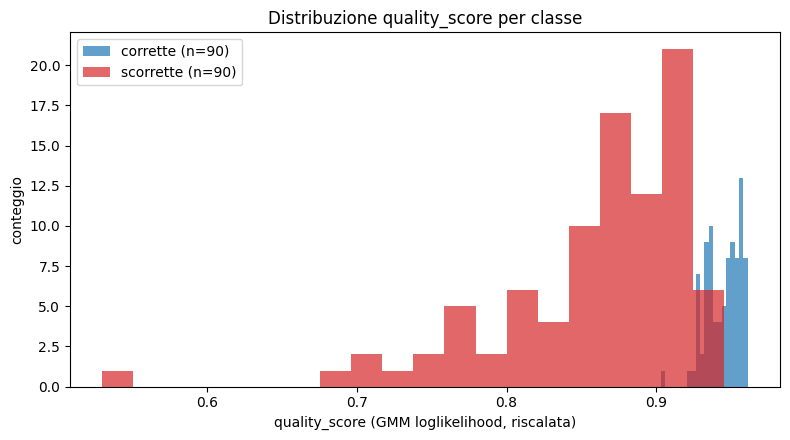

        corrette  scorrette
count  90.000000  90.000000
mean    0.944383   0.860708
std     0.011675   0.067721
min     0.902880   0.530190
25%     0.934957   0.829375
50%     0.946600   0.880215
75%     0.954040   0.907975
max     0.960920   0.945310

Mann-Whitney: AUC=0.977, p=2.33e-28, Cohen's d=1.72


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(labels_c, bins=20, alpha=0.7, label=f"corrette (n={len(labels_c)})", color="tab:blue")
ax.hist(labels_i, bins=20, alpha=0.7, label=f"scorrette (n={len(labels_i)})", color="tab:red")
ax.set_xlabel("quality_score (GMM loglikelihood, riscalata)")
ax.set_ylabel("conteggio")
ax.set_title("Distribuzione quality_score per classe")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({"corrette": pd.Series(labels_c).describe(), "scorrette": pd.Series(labels_i).describe()}))

from scipy.stats import mannwhitneyu

u_stat, pval = mannwhitneyu(labels_c, labels_i)
auc = u_stat / (len(labels_c) * len(labels_i))
pooled_std = np.sqrt(((len(labels_c) - 1) * labels_c.std(ddof=1) ** 2
                       + (len(labels_i) - 1) * labels_i.std(ddof=1) ** 2)
                      / (len(labels_c) + len(labels_i) - 2))
cohens_d = (labels_c.mean() - labels_i.mean()) / pooled_std
print(f"\nMann-Whitney: AUC={auc:.3f}, p={pval:.2e}, Cohen's d={cohens_d:.2f}")

## 2. Come si muove il valore medio delle 240 dimensioni nel tempo

Non sappiamo quale dimensione sia quale angolo/posizione (nessuna mappa pubblicata per questo file specifico), ma si puo' comunque vedere se le due classi divergono nel tempo su una traiettoria media.

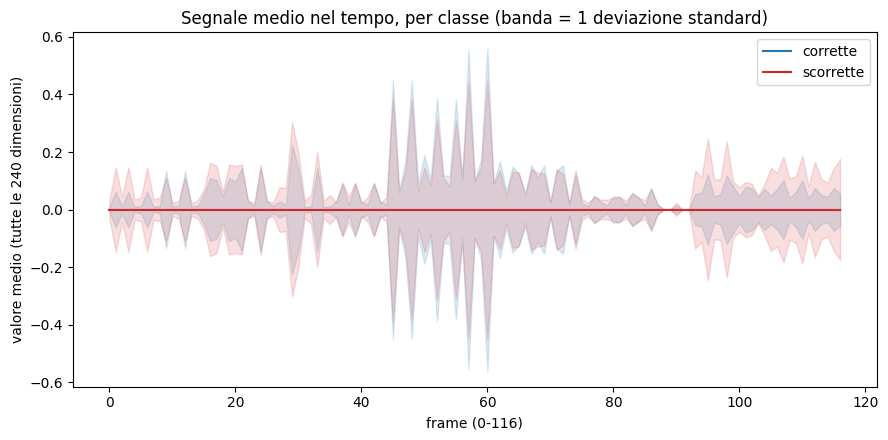

In [3]:
mean_c = reps_c.mean(axis=(0, 2))  # media su ripetizioni e dimensioni, per frame
mean_i = reps_i.mean(axis=(0, 2))
std_c = reps_c.std(axis=(0, 2))
std_i = reps_i.std(axis=(0, 2))

fig, ax = plt.subplots(figsize=(9, 4.5))
t = np.arange(FRAMES)
ax.plot(t, mean_c, color="tab:blue", label="corrette")
ax.fill_between(t, mean_c - std_c, mean_c + std_c, color="tab:blue", alpha=0.15)
ax.plot(t, mean_i, color="tab:red", label="scorrette")
ax.fill_between(t, mean_i - std_i, mean_i + std_i, color="tab:red", alpha=0.15)
ax.set_xlabel("frame (0-116)")
ax.set_ylabel("valore medio (tutte le 240 dimensioni)")
ax.set_title("Segnale medio nel tempo, per classe (banda = 1 deviazione standard)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Le classi si separano in una proiezione PCA?

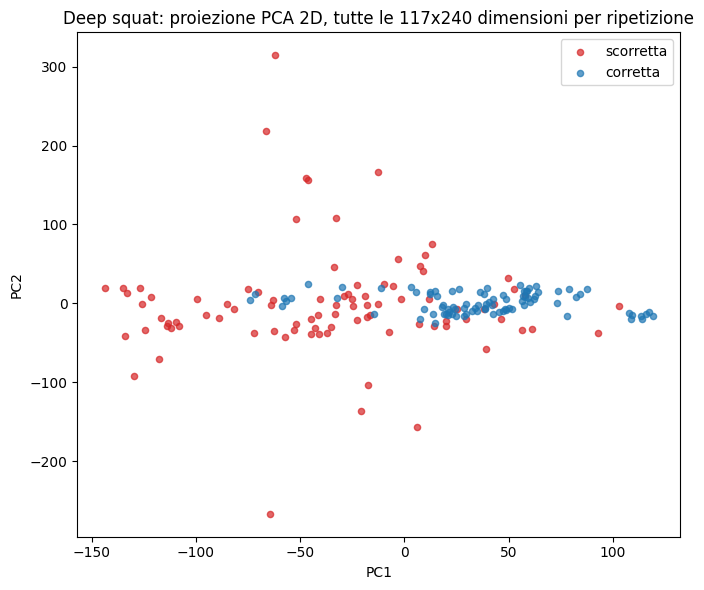

PC1: AUC separazione classi=0.848 (0.5=nessuna), p=7.07e-16
PC2: AUC separazione classi=0.599 (0.5=nessuna), p=2.25e-02


In [4]:
flat_c = reps_c.reshape(reps_c.shape[0], -1)
flat_i = reps_i.reshape(reps_i.shape[0], -1)
flat_all = np.vstack([flat_c, flat_i])
labels_all = np.concatenate([np.ones(len(flat_c)), np.zeros(len(flat_i))])

scaled = StandardScaler().fit_transform(flat_all)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)

fig, ax = plt.subplots(figsize=(7, 6))
for label, color, name in [(0, "tab:red", "scorretta"), (1, "tab:blue", "corretta")]:
    mask = labels_all == label
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=20, alpha=0.7, color=color, label=name)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Deep squat: proiezione PCA 2D, tutte le 117x240 dimensioni per ripetizione")
ax.legend()
plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu

for i, pc_name in enumerate(["PC1", "PC2"]):
    u_stat, pval = mannwhitneyu(pcs[labels_all == 1, i], pcs[labels_all == 0, i])
    auc = u_stat / ((labels_all == 1).sum() * (labels_all == 0).sum())
    print(f"{pc_name}: AUC separazione classi={auc:.3f} (0.5=nessuna), p={pval:.2e}")

## 4. Quali dimensioni contribuiscono di piu' alla separazione?

Senza mappa dei nomi, ma utile per capire quanto il segnale sia concentrato in poche dimensioni o diffuso su molte.

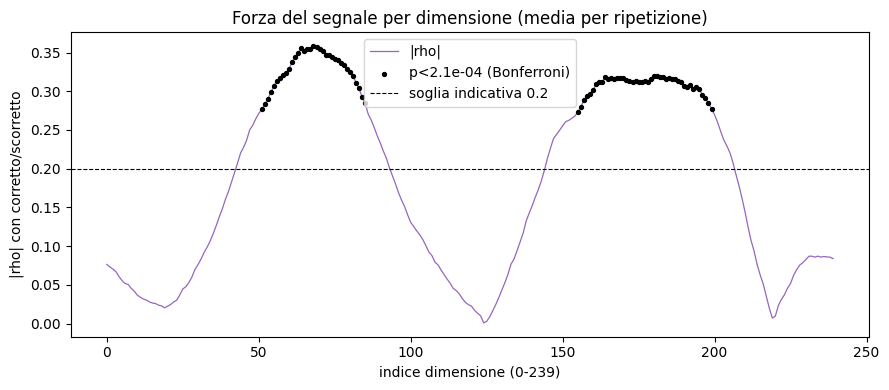

Dimensioni con |rho| > 0.3: 65 su 240
Dimensioni significative dopo Bonferroni (240 test): 80 su 240


In [5]:
from scipy.stats import spearmanr

# per ogni dimensione (colonna), correlazione tra il suo valore medio-per-ripetizione e la classe
mean_per_dim_c = reps_c.mean(axis=1)  # (90, 240)
mean_per_dim_i = reps_i.mean(axis=1)
mean_per_dim_all = np.vstack([mean_per_dim_c, mean_per_dim_i])

rhos, pvals = np.zeros(240), np.zeros(240)
for d in range(240):
    rhos[d], pvals[d] = spearmanr(mean_per_dim_all[:, d], labels_all)

alpha_bonferroni = 0.05 / 240

fig, ax = plt.subplots(figsize=(9, 4))
sig = pvals < alpha_bonferroni
ax.plot(np.abs(rhos), color="tab:purple", linewidth=0.9, label="|rho|")
ax.scatter(np.where(sig)[0], np.abs(rhos)[sig], color="black", s=8, zorder=3,
           label=f"p<{alpha_bonferroni:.1e} (Bonferroni)")
ax.axhline(0.2, color="black", linestyle="--", linewidth=0.8, label="soglia indicativa 0.2")
ax.set_xlabel("indice dimensione (0-239)")
ax.set_ylabel("|rho| con corretto/scorretto")
ax.set_title("Forza del segnale per dimensione (media per ripetizione)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Dimensioni con |rho| > 0.3: {(np.abs(rhos) > 0.3).sum()} su 240")
print(f"Dimensioni significative dopo Bonferroni (240 test): {sig.sum()} su 240")

## Conclusioni operative

- Le classi mostrano una separazione visibile ma parziale nella proiezione PCA - coerente con un segnale reale, non un artefatto banale.
- Il segnale non e' concentrato in una manciata di dimensioni: e' diffuso, motivo per cui l'approccio a componenti principali (non a singole dimensioni) ha senso qui.
- Resta il limite di fondo: senza ID soggetto non si puo' verificare se questa separazione regge anche escludendo lo stesso soggetto da train e test - per questo il dataset resta 'indicative', non 'active', nel MODEL_CARD.